### E-commerce Customer Behavior & KPI Analysis
This notebook analyzes key performance indicators (KPIs) to better understand user behavior and purchase intention in an e-commerce setting.

The analysis aims to:
- Compare behavioral differences between new and returning visitors
- Identify engagement patterns associated with higher conversion
- Track monthly conversion trends

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
df = pd.read_csv('processed_online_shoppers_intention.csv')

### 1. KPI Overview
This section provides a high-level comparison of key metrics across overall users, new visitors, and returning visitors, including:
- Conversion rate
- Average session duration
- Average pages viewed

In [9]:
kpi_summary = pd.DataFrame({'segment':['overall', 'new_visitors', 'returning_visitors'],
                            'conversion_rate':[df['Revenue'].mean(), 
                                               df[df['is_returning']==0]['Revenue'].mean(), 
                                               df[df['is_returning']==1]['Revenue'].mean()],
                            'avg_duration':[df['total_duration'].mean(),
                                            df[df['is_returning']==0]['total_duration'].mean(),
                                            df[df['is_returning']==1]['total_duration'].mean()],
                            'avg_page':[df['total_pages'].mean(),
                                        df[df['is_returning']==0]['total_pages'].mean(),
                                        df[df['is_returning']==1]['total_pages'].mean()]
                                        }).round(4)

kpi_summary

,segment,conversion_rate,avg_duration,avg_page
0,overall,0.1547,1310.0372,34.5502
1,new_visitors,0.2462,742.6325,20.6144
2,returning_visitors,0.1393,1405.7071,36.8999


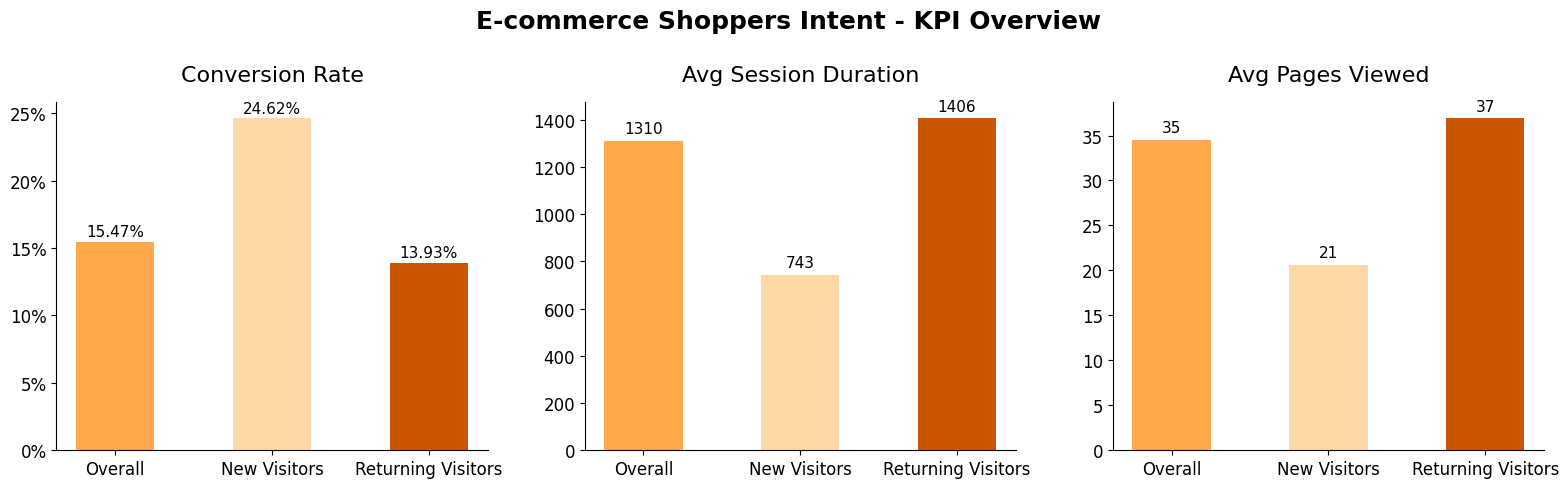

In [10]:
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 12,     
    'xtick.labelsize': 12,
    'ytick.labelsize': 12})

kpi_summary['segment'] = ['Overall', 'New Visitors', 'Returning Visitors']

fig, axes = plt.subplots(1, 3, figsize=(16,5))
fig.suptitle('E-commerce Shoppers Intent - KPI Overview', fontsize=18, fontweight='bold')

colors = ['#FFA94D', '#FFD8A8', '#CC5500']
bar_width = 0.5

# Conversion
axes[0].bar(kpi_summary['segment'], kpi_summary['conversion_rate'], color=colors, width=bar_width)
axes[0].set_title('Conversion Rate', pad=15)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
for nbar, con_rate in enumerate(kpi_summary['conversion_rate']):
    axes[0].text(nbar, con_rate + 0.002, f'{con_rate:.2%}', ha='center', va='bottom', fontsize=11)

# Duration
axes[1].bar(kpi_summary['segment'], kpi_summary['avg_duration'], color=colors, width=bar_width)
axes[1].set_title('Avg Session Duration', pad=15)
for nbar, avg_dur in enumerate(kpi_summary['avg_duration']):
    axes[1].text(nbar, avg_dur + 20, f'{avg_dur:.0f}', ha='center', va='bottom', fontsize=11)

# Pages
axes[2].bar(kpi_summary['segment'], kpi_summary['avg_page'], color=colors, width=bar_width)
axes[2].set_title('Avg Pages Viewed', pad=15)
for nbar, avg_pages in enumerate(kpi_summary['avg_page']):
    axes[2].text(nbar, avg_pages + 0.5, f'{avg_pages:.0f}', ha='center', va='bottom', fontsize=11)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('images/kpi_overview.png', dpi=300, bbox_inches='tight')
plt.show()

#### Key Insights

- New visitors show a higher conversion rate than returning visitors in this dataset.
- Returning visitors spend more time and view more pages on average.

This suggests that browsing intensity does not always directly translate into higher conversion.

### 2. Behavioral Analysis

In this section, I analyze how product-related engagement influences conversion behavior.

Product engagement is measured based on the time users spend on product-related pages. 
I categorize visitors into four engagement levels using quartiles.

In [11]:
conversion_by_product_duration = df.groupby(['is_returning', 'productrelated_intent'])['Revenue'].mean().reset_index()

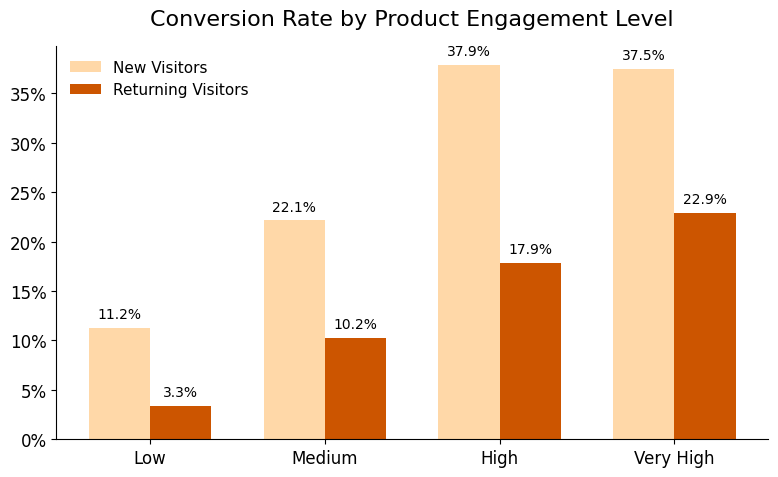

In [12]:
cpd_plot = conversion_by_product_duration.copy()
cpd_plot['visitor_type'] = cpd_plot['is_returning'].map({0:'New Visitors', 1: 'Returning Visitors'})
intent_order = ['low', 'medium', 'high', 'very_high']
cpd_plot['productrelated_intent'] = pd.Categorical(cpd_plot['productrelated_intent'],categories=intent_order,
                                                   ordered=True)
cpd_plot = cpd_plot.sort_values(['productrelated_intent', 'visitor_type'])

pivot_cpd = cpd_plot.pivot(index='productrelated_intent', columns='visitor_type', values='Revenue')

x = np.arange(len(pivot_cpd.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
colors = ['#FFD8A8', '#CC5500']
ax.bar(x - width/2, pivot_cpd['New Visitors'], width, label='New Visitors', color=colors[0])
ax.bar(x + width/2, pivot_cpd['Returning Visitors'], width, label='Returning Visitors', color=colors[1])

ax.set_title('Conversion Rate by Product Engagement Level', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(['Low', 'Medium', 'High', 'Very High'])
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

for i in range(len(pivot_cpd)):
    ax.text(i - width/2, pivot_cpd['New Visitors'].iloc[i] + 0.01,
            f"{pivot_cpd['New Visitors'].iloc[i]:.1%}", ha='center', fontsize=10)

    ax.text(i + width/2, pivot_cpd['Returning Visitors'].iloc[i] + 0.01,
            f"{pivot_cpd['Returning Visitors'].iloc[i]:.1%}", ha='center', fontsize=10)
    
ax.legend(frameon=False, fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('images/product_engagement.png', dpi=300, bbox_inches='tight')
plt.show()

#### Key Insights
- Conversion rate increases significantly as product engagement level increases.
- This trend is especially strong for new visitors, where conversion rises sharply from low to high engagement levels.

This suggests that encouraging users to spend more time on product-related pages can significantly improve conversion performance.

### 3. Trend Analysis
This section examines how conversion rates vary across months for new and returning visitors.
The goal is to identify whether seasonal patterns or monthly fluctuations exist across visitor types.

In [13]:
conversion_by_month = df.groupby(['is_returning','Month'])['Revenue'].mean().reset_index()

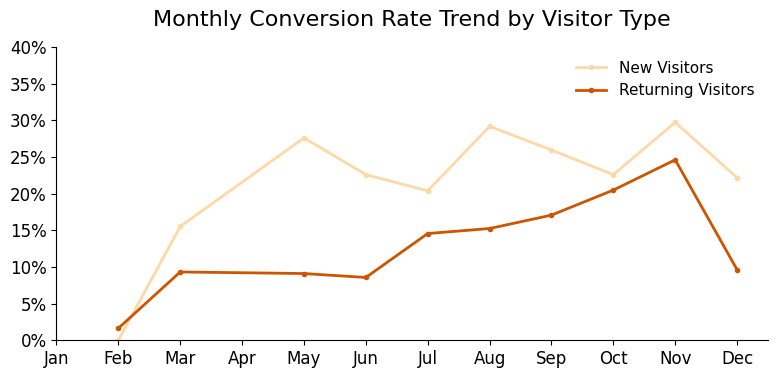

In [14]:
month_plot = conversion_by_month.copy()
month_plot['visitor_type'] = month_plot['is_returning'].map({0:'New Visitors', 1:'Returning Visitors'})

month_plot = month_plot.sort_values('Month')

pivot_month = month_plot.pivot(index='Month', columns='visitor_type', values='Revenue' )

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize = (8,4))
colors = ['#FFD8A8', '#CC5500']

ax.plot(pivot_month.index, pivot_month['New Visitors'],
        marker='.', label='New Visitors', color=colors[0], linewidth=2)
ax.plot(pivot_month.index, pivot_month['Returning Visitors'],
        marker='.', label='Returning Visitors', color=colors[1], linewidth=2)

ax.set_title('Monthly Conversion Rate Trend by Visitor Type', pad=15)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.legend(frameon=False, fontsize=11 )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks(range(1,13))
ax.set_xticklabels(month_labels)
ax.set_ylim(0, 0.4)
plt.tight_layout()
plt.savefig('images/monthly_trend.png', dpi=300, bbox_inches='tight')
plt.show()

#### Key Insights

- Conversion rates vary across months for both new and returning visitors.
- New visitors generally show higher conversion rates than returning visitors throughout the year.
- Returning visitors reach their highest conversion rate in November, suggesting that this segment may respond strongly during certain periods of the year.

The monthly trend suggests that conversion performance may be influenced by seasonal or temporal factors, which could be explored further with additional business context.

### Conclusion

- New visitors exhibit higher conversion rates, while returning visitors show stronger engagement in terms of browsing behavior.
- Product-related engagement is a key driver of conversion, particularly for new visitors.
- Conversion rates vary across months, indicating that user behavior may also be influenced by temporal factors.

These findings suggest that improving product engagement and understanding user segmentation can help enhance overall conversion performance.